# Параметрическое исследование модели Лотки–Вольтерры

В полном плане изменяются рождаемость жертв `alpha` и смертность хищников
`gamma`. Для каждого опыта измеряются период, амплитуды и сохранение интеграла.

Lotka–Volterra parameter grid: 16 combinations


Observed periods: 14.4–142.93
Maximum invariant drift: 9.866979233663642e-9


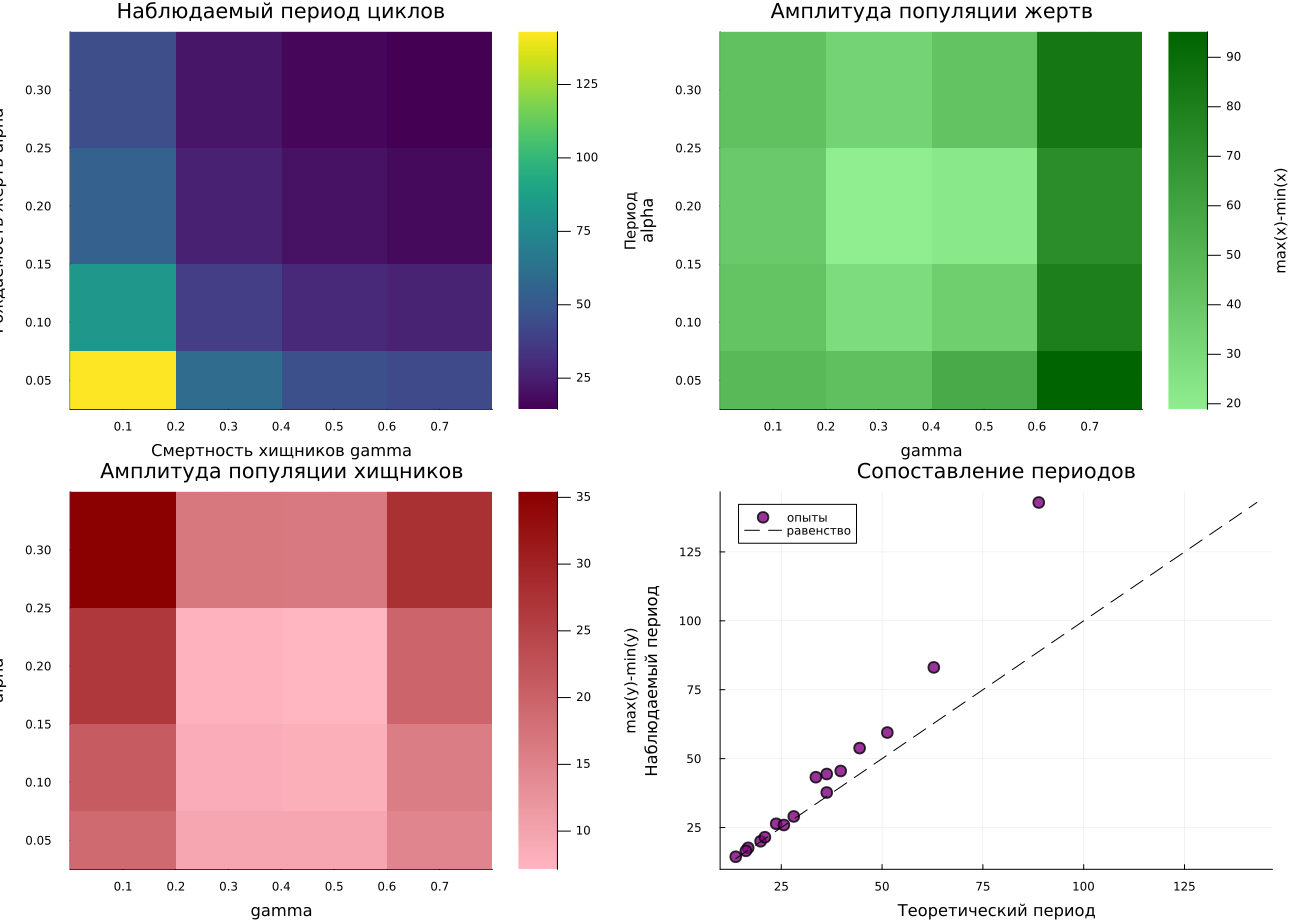

In [1]:
using DrWatson
@quickactivate "BasicModelsLab"
using BasicModelsLab.BasicModels
using CSV, DataFrames, JLD2, Plots, Statistics

script_name = "lv_ode__param"
mkpath(datadir(script_name))
mkpath(plotsdir(script_name))
gr()

alphas = [0.05, 0.1, 0.2, 0.3]
gammas = [0.1, 0.3, 0.5, 0.7]
beta = 0.02
delta = 0.01
u0 = [40.0, 9.0]
rows = NamedTuple[]

function estimate_period(signal, time)
    peak_times = Float64[]
    for index in 2:(length(signal) - 1)
        signal[index] > signal[index - 1] && signal[index] > signal[index + 1] &&
            push!(peak_times, time[index])
    end
    return length(peak_times) >= 2 ? mean(diff(peak_times)) : NaN
end

for alpha in alphas, gamma in gammas
    p = [alpha, beta, delta, gamma]
    frame = lv_dataframe(solve_lv(; u0, p, tspan=(0.0, 600.0), saveat=0.2), p)
    conserved = invariant_lv(frame.prey, frame.predator, p)
    push!(rows, (
        alpha=alpha, gamma=gamma, x_star=gamma / delta, y_star=alpha / beta,
        period_theory=2pi / sqrt(alpha * gamma),
        period_observed=estimate_period(frame.prey, frame.t),
        prey_min=minimum(frame.prey), prey_max=maximum(frame.prey),
        predator_min=minimum(frame.predator), predator_max=maximum(frame.predator),
        invariant_drift=maximum(abs.(conserved .- conserved[1])),
    ))
end

scan = DataFrame(rows)
CSV.write(datadir(script_name, "lv_parameter_grid.csv"), scan)
@save datadir(script_name, "lv_parameter_grid.jld2") alphas gammas beta delta scan

println("Lotka–Volterra parameter grid: $(nrow(scan)) combinations")
println("Observed periods: $(round(minimum(scan.period_observed), digits=2))–$(round(maximum(scan.period_observed), digits=2))")
println("Maximum invariant drift: $(maximum(scan.invariant_drift))")

period_matrix = reshape(scan.period_observed, length(gammas), length(alphas))'
prey_amplitude = reshape(scan.prey_max .- scan.prey_min, length(gammas), length(alphas))'
predator_amplitude = reshape(scan.predator_max .- scan.predator_min, length(gammas), length(alphas))'

period_heat = heatmap(gammas, alphas, period_matrix;
    xlabel="Смертность хищников gamma", ylabel="Рождаемость жертв alpha",
    colorbar_title="Период", title="Наблюдаемый период циклов", c=:viridis,
    size=(820, 520))
prey_heat = heatmap(gammas, alphas, prey_amplitude;
    xlabel="gamma", ylabel="alpha", colorbar_title="max(x)-min(x)",
    title="Амплитуда популяции жертв", c=:greens, size=(820, 520))
predator_heat = heatmap(gammas, alphas, predator_amplitude;
    xlabel="gamma", ylabel="alpha", colorbar_title="max(y)-min(y)",
    title="Амплитуда популяции хищников", c=:reds, size=(820, 520))
agreement = scatter(scan.period_theory, scan.period_observed;
    xlabel="Теоретический период", ylabel="Наблюдаемый период",
    title="Сопоставление периодов", label="опыты", color=:purple,
    ms=6, alpha=.8, size=(820, 520))
limits = extrema(vcat(scan.period_theory, scan.period_observed))
plot!(agreement, collect(limits), collect(limits); label="равенство", color=:black, ls=:dash)

panel = plot(period_heat, prey_heat, predator_heat, agreement;
             layout=(2, 2), size=(1300, 920))
savefig(period_heat, plotsdir(script_name, "lv_period_heatmap.png"))
savefig(prey_heat, plotsdir(script_name, "lv_prey_amplitude.png"))
savefig(predator_heat, plotsdir(script_name, "lv_predator_amplitude.png"))
savefig(agreement, plotsdir(script_name, "lv_period_agreement.png"))
savefig(panel, plotsdir(script_name, "lv_parameter_panel.png"))

display(panel)